In [1]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model = 'text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='imcome_tex_collection',
    persist_directory='./chroma'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [2]:
from typing import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
def retrieve(satate: AgentState):
    query = satate['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [5]:

from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    query = state['query']
    context = state['context']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [6]:
from typing import Literal

doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    query = state['query']
    context = state['context']
    print(f'context == {context}')

    doc_relevance_rag_chain = doc_relevance_prompt | llm
    response = doc_relevance_rag_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response == {response}')

    if response['Score'] == 1:
        return 'relevant'
    return 'irrelevant'

In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
사전: {dictionary}
질문: {{query}}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}


## Hallucination

- LangChain에서 제공하는 Prompt
- [langchain-ai/rag-answer-hallucination](https://smith.langchain.com/hub/langchain-ai/rag-answer-hallucination)

In [8]:
hallucination_prompt = client.pull_prompt("langchain-ai/rag-answer-hallucination")

def check_hallucination(state: AgentState) -> Literal['hallucinated', 'not_hallucinated']:
    answer = state["answer"]
    context = state["context"]
    hallucination_chain = hallucination_prompt | llm
    response = hallucination_chain.invoke({'student_answer':answer, 'documents': context})
    print(f"hallucination response: {response}")

    if response['Score'] == 1:
        return 'not_hallucinated'
    return 'hallucinated'

In [9]:
"""check_hallucination 검증"""

query = "연봉 5천만원인 직장인의 소득세는?"
context = retriever.invoke(query)
generate_state = {'query': query, 'context': context}
answer = generate(generate_state)
print(f"answer: {answer}")

hallucination_state = {'answer': answer, 'context': context}
check_hallucination(hallucination_state)

answer: {'answer': AIMessage(content='연봉 5천만 원인 직장인의 소득세는 근로소득 기본세율이 적용됩니다. 총급여액에 따른 소득공제와 실제 세율 계산을 위해서는 구체적인 소득세율 표가 필요합니다. 제공된 정보로는 정확한 세율이나 공제액 표가 없어 구체적인 소득세액을 계산할 수 없습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 2141, 'total_tokens': 2226, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cb9a9989f4', 'id': 'chatcmpl-DcPbx85NyUsJQifLeZzA3jCKsc9lt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dfbe0-79bc-7c51-845f-2b813d0e5086-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2141, 'output_tokens': 85, 'total_tokens': 2226, 'input_token_details': {'audio': 0, 'cache_read': 1024}, 'output_token_detail

'hallucinated'

In [10]:
"""
위에서 작성한 check_hallucination() 함수에서 문서 기반으로 답변이 잘되었음에도 환각으로 판단하고 있음
-> 수동으로 프롬프트를 작성
"""

from pydantic import BaseModel, Field

class HallucinationResult(BaseModel):
    Score: int = Field(..., description="1: 문서에 근거한 답변, 0: 문서에 근거하지 않은 답변")
    Explanation: str = Field(..., description="채점 과정과 결론이 타당한지에 대한 한글 설명")


custom_hallucination_llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0
).with_structured_output(HallucinationResult)


custom_hallucination_prompt = PromptTemplate.from_template(
"""
당신은 학생의 답변이 문서(한국의 소득세법)에 기반한 답변인지 평가하는 교사입니다.
학생의 답변: {student_answer}
문서: {documents}
""")


def check_custom_hallucination(state: AgentState) -> Literal['hallucinated', 'not_hallucinated']:
    answer = state["answer"]
    context = state["context"]
    hallucination_chain = custom_hallucination_prompt | custom_hallucination_llm
    response = hallucination_chain.invoke({'student_answer': answer, 'documents': context})
    print(f"custom hallucination response: {response}")

    if response.Score == 1:
        return 'not_hallucinated'
    return 'hallucinated'

In [11]:
"""check_custom_hallucination() 검증"""
check_custom_hallucination(hallucination_state)

custom hallucination response: Score=1 Explanation='학생의 답변은 문서에 기반한 것으로 보입니다. 문서에서 근로소득에 대한 기본세율이 언급되어 있으며, 학생은 연봉 5천만 원인 직장인의 소득세가 근로소득 기본세율에 따라 계산된다고 설명하고 있습니다. 또한, 학생은 구체적인 소득세율 표가 필요하다고 언급했는데, 이는 문서에 제공된 정보로는 구체적인 세율이나 공제액을 계산할 수 없다는 점을 반영한 것입니다. 따라서 학생의 답변은 문서의 내용을 적절히 반영하고 있습니다.'


'not_hallucinated'

## Answer Question

- AI 답변이 사용자의 질문과 관련이 있는지 검사
- [langchain-ai/rag-answer-helpfulness](https://smith.langchain.com/hub/langchain-ai/rag-answer-helpfulness)

In [12]:
helpfulness_prompt = client.pull_prompt("langchain-ai/rag-answer-helpfulness")

def check_helpfulness_grader(state: AgentState) -> Literal['helpful', 'unhelpful']:
    query = state["query"]
    answer = state["answer"]
    helpfulness_chain = helpfulness_prompt | llm
    response = helpfulness_chain.invoke({'student_answer': answer, 'question': query})
    print(f"helpfulness response: {response}")
    
    if response['Score'] == 1:
        return 'helpful'
    return 'unhelpful'

def check_helpfulness(state: AgentState):
    return state

In [13]:
helpfulness_state = {'query': query, 'answer': answer}
check_helpfulness(helpfulness_state)

{'query': '연봉 5천만원인 직장인의 소득세는?',
 'answer': {'answer': AIMessage(content='연봉 5천만 원인 직장인의 소득세는 근로소득 기본세율이 적용됩니다. 총급여액에 따른 소득공제와 실제 세율 계산을 위해서는 구체적인 소득세율 표가 필요합니다. 제공된 정보로는 정확한 세율이나 공제액 표가 없어 구체적인 소득세액을 계산할 수 없습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 2141, 'total_tokens': 2226, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cb9a9989f4', 'id': 'chatcmpl-DcPbx85NyUsJQifLeZzA3jCKsc9lt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dfbe0-79bc-7c51-845f-2b813d0e5086-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2141, 'output_tokens': 85, 'total_tokens': 2226, 'input_token_details': {'audio': 0, 'cach

In [14]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
#graph_builder.add_node('check_doc_relevance', check_doc_relevance)
#graph_builder.add_node('check_custom_hallucination', check_custom_hallucination)
graph_builder.add_node('check_helpfulness', check_helpfulness)

In [15]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant':'generate',
        'irrelevant': END
    }
)
graph_builder.add_conditional_edges(
    'generate',
    check_custom_hallucination,
    {
        'hallucinated': 'generate',
        'not_hallucinated':'check_helpfulness'
    }
)
graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful': END,
        'unhelpful': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'retrieve')

In [16]:
graph = graph_builder.compile()

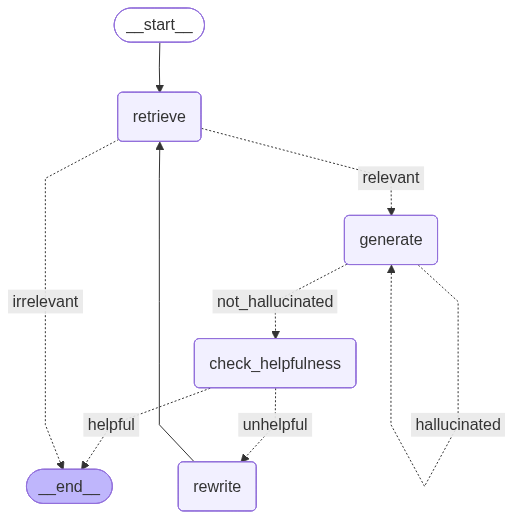

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
initial_state = {'query': '배가 고파요'}
graph.invoke(initial_state)

context == [Document(id='fdf01c22-c31b-4707-b14c-a73205d1911c', metadata={'source': './documents/income_tax.txt'}, page_content='바. 「국민연금법」에 따라 받는 반월이십금(사망으로 받는 것에 해당한다) 및 사망일시금\n   사. 「공무원연금법」, 「공무원 재해보상법」, 「군인연금법」, 「군인 재해보상법」, 「사립학교교직원 연금법」 또는 「법정우권수습법」에 따라 받는 공무상요양비·요양급여·장해일시금·비공무상 장해일시금·비직무상 장해월시급·장애보상금·사망보상금·유족급 생활비·퇴직유족 급시금·유족연금급시금·퇴직육월입산기금·퇴직유족연금월입금·순직유족연금료·유족연급가급·퇴직유족연금가급·퇴직유족연금기금급·유족연금특별가기·순직유족연금특별가기·퇴직유족연금특별파기금금·퇴직 유족연금월입급가금·순직유족연금 특수보장·직무상유족 상종보상·학진수육전유족특수보상·재핵자조급·재내부조급도דות 치료·정산신기 장해·병일보로 인한 휴직기간에 받는 급여\n   아. 대통령령으로 정하는 착자금'), Document(id='4fceb2ae-85ec-4d03-b08d-b7c34992b982', metadata={'source': './documents/income_tax.txt'}, page_content='바. 「국민연금법」에 따라 받는 반월이십금(사망으로 받는 것에 해당한다) 및 사망일시금\n   사. 「공무원연금법」, 「공무원 재해보상법」, 「군인연금법」, 「군인 재해보상법」, 「사립학교교직원 연금법」 또는 「법정우권수습법」에 따라 받는 공무상요양비·요양급여·장해일시금·비공무상 장해일시금·비직무상 장해월시급·장애보상금·사망보상금·유족급 생활비·퇴직유족 급시금·유족연금급시금·퇴직육월입산기금·퇴직유족연금월입금·순직유족연금료·유족연급가급·퇴직유족연금가급·퇴직유족연금기금급·유족연금특별가기·순직유족연금특별가기·퇴직유족연금특별파기금금·퇴직 유족연금월입급가금·순직유족연금 특수보장·직무상유족 상종보상·학진수육

{'query': '배가 고파요',
 'context': [Document(id='fdf01c22-c31b-4707-b14c-a73205d1911c', metadata={'source': './documents/income_tax.txt'}, page_content='바. 「국민연금법」에 따라 받는 반월이십금(사망으로 받는 것에 해당한다) 및 사망일시금\n   사. 「공무원연금법」, 「공무원 재해보상법」, 「군인연금법」, 「군인 재해보상법」, 「사립학교교직원 연금법」 또는 「법정우권수습법」에 따라 받는 공무상요양비·요양급여·장해일시금·비공무상 장해일시금·비직무상 장해월시급·장애보상금·사망보상금·유족급 생활비·퇴직유족 급시금·유족연금급시금·퇴직육월입산기금·퇴직유족연금월입금·순직유족연금료·유족연급가급·퇴직유족연금가급·퇴직유족연금기금급·유족연금특별가기·순직유족연금특별가기·퇴직유족연금특별파기금금·퇴직 유족연금월입급가금·순직유족연금 특수보장·직무상유족 상종보상·학진수육전유족특수보상·재핵자조급·재내부조급도דות 치료·정산신기 장해·병일보로 인한 휴직기간에 받는 급여\n   아. 대통령령으로 정하는 착자금'),
  Document(id='4fceb2ae-85ec-4d03-b08d-b7c34992b982', metadata={'source': './documents/income_tax.txt'}, page_content='바. 「국민연금법」에 따라 받는 반월이십금(사망으로 받는 것에 해당한다) 및 사망일시금\n   사. 「공무원연금법」, 「공무원 재해보상법」, 「군인연금법」, 「군인 재해보상법」, 「사립학교교직원 연금법」 또는 「법정우권수습법」에 따라 받는 공무상요양비·요양급여·장해일시금·비공무상 장해일시금·비직무상 장해월시급·장애보상금·사망보상금·유족급 생활비·퇴직유족 급시금·유족연금급시금·퇴직육월입산기금·퇴직유족연금월입금·순직유족연금료·유족연급가급·퇴직유족연금가급·퇴직유족연금기금급·유족연금특별가기·순직유족연금특별가기·퇴직유족연금특별파기금금·퇴직 유족연금월입급가금·순직유족

In [27]:
initial_state = {'query': query}
graph.invoke(initial_state)

context == [Document(id='fbe91ac3-b02c-4310-b25f-9493c552c9aa', metadata={'source': './documents/income_tax.txt'}, page_content='2. 배당소득에 대해서는 다음에 규정하는 세율\n   가. 제17조제1항제3호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25\n   나. 그 밖의 배당소득에 대해서는 100분의 14\n3. 원천징수대상 사업소득에 대해서는 100분의 3. 다만, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클럽 운영업 중 프로스포츠구단과의 계약에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다. \n4. 근로소득에 대해서는 기본세율. 다만, 일용근로자의 근로소득에 대해서는 100분의 6으로 한다.\n5. 공적연금소득에 대해서는 기본세율\n   5의2.제20조의3제1항제1호나목 및 다음에 따른 연금계좌 납입액이나 운용실적에 따라 증가된 금액을 연금수령한 연금소득자에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n   가. 연금소득자의 나이에 따른 다음의 세율\n| 나이(연금수령일 현재) | 세율     |\n   |------------------|--------|\n   | 70세 미만            | 100분의 5 |\n   | 70세 이상 80세 미만   | 100분의 4 |\n   | 80세 이상            | 100분의 3 |\n나. 삭제 <2014. 12. 23.>\n소득세법\n5의3. 제20조의3제1항제2호가목에 따라 퇴직소득을 연금수령하는 연금소득에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 연금 실제 수령연차 및 연금외수령 원천징수세율은 구체적인 내용은 대통령령으로 정한다.\n  가. 연금 실제 수령연차가 10년 이하인 경우: 연금외수령 원천징수세율의 100분의 70\n  나. 연금 실제 수령연차가 10년을

{'query': '거주자 연봉 5천만원의 소득세는?',
 'context': [Document(id='289e9e4a-2425-4ae1-a933-98d388b6780e', metadata={'source': './documents/income_tax.txt'}, page_content='| 총급여액                      | 공제액                                             |\n|-------------------------------|---------------------------------------------------|\n| 500만원 이하                     | 총 급여액의 100분의 70                               |\n| 500만원 초과 1천 500만원 이하 | 350만원+(500만원을 초과하는 금액의 100분의 40)        |\n| 1천 500만원 초과 3천 500만원 이하 | 750만원+(1천 500만원을 초과하는 경우의 100분의 15)   |\n| 3천 500만원 초과 1억원 이하       | 1천 200만원+(3천 500만원을 초과하는 금액의 100분의 5)|\n| 1억원 초과                      | 1천 475만원+(1억원을 초과하는 금액의 100분의 2)       |\n② 일용근로자에 대한 공제액은 제1항에도 불구하고 1일 15만원으로 한다.<개정 2018. 12. 31.>\n③ 근로소득이 있는 거주자의 해당 과세기간의 총급여액이 제1항 또는 제2항의 공제액에 미달하는 경우에는 그 총급여액을 공제액으로 한다.\n④ 제1항부터 제3항까지의 규정에 따른 공제를 “근로소득공제”라 한다.\n⑤ 제1항의 경우에 2인 이상으로부터 근로소득을 받는 사람(일용근로자는 제외한다)에 대하여는 그 근로소득의 합계액을 총급여액으로 하여 제1항에 따라 계산한 근로소득공제액을 총급여액에서 공제한다.<개정 2010. 12. 27.>\n⑥